# Multicoordinate Wave Project

Generate one wave project containing several coordinate systems and inspect the
coordinate-specific artifacts.

Navigation: [Index](../index.ipynb) |
Previous: [GeneralRFM and Fisheye Coordinates](../4-curvilinear/generalrfm_and_fisheye.ipynb) |
Next: [BHaH Project Anatomy](../5-infrastructures/bhah_project_anatomy.ipynb)

## Learning Goals

- Generate one project that contains several coordinate systems.
- Find which directories belong to which coordinates.
- Run the executable and inspect one diagnostic output per coordinate choice.

## Words for This Notebook

- **Coordinate option:** one grid choice available inside the same generated project.
- **Runtime parameter:** a value chosen when the program runs, without regenerating code.
- **Diagnostic file:** a text file written by the run so results can be compared.
- **Executable:** the compiled program shared by the coordinate options.
- **Relative error:** the sampled difference between numerical and exact values,
  divided by the exact value at the diagnostic point.
- **BHaH:** the NRPy code-writing infrastructure used by this generator.
- **Method of Lines (MoL):** the time-stepping structure used by the generated code.

Use the code cells actively: first predict what should happen, then run the cell,
then explain the output in plain language.

## Table of Contents

- [Project Workflow Map](#project-workflow-map)
- [Challenges](#challenges)
- [Coordinate Option Catalog](#coordinate-option-catalog)
- [Generate Project](#generate-project)
- [Inspect Coordinate-Specific Artifacts](#inspect-coordinate-specific-artifacts)
- [Validate Multicoordinate Diagnostics](#validate-multicoordinate-diagnostics)
- [Plot Multicoordinate Diagnostics](#plot-multicoordinate-diagnostics)

## Project Workflow Map

The multicoordinate project uses one executable but generates coordinate-aware
pieces for each grid choice.

| Stage | Generated artifact | What it contributes |
| --- | --- | --- |
| Coordinate catalog | per-coordinate directories | one RHS per coordinate option |
| Shared runtime setup | parameter file and `main.c` | one executable chooses and runs all grids |
| Boundary handling | `apply_bcs_*.c`, `bcstruct_set_up.c` | ghost-zone fills |
| Diagnostics | `out0d-grid*-<CoordSystem>-*.txt` | one sampled error file per coordinate option |

## Challenges

- **Shared executable:** one program must run several coordinate options from a
  shared runtime configuration.
- **Coordinate-specific sources:** each coordinate option writes its own RHS
  source directory inside the generated project.
- **Separate diagnostics:** each coordinate run writes a file that must be read
  and checked independently.

| Challenge | Addressed By |
| --- | --- |
| Shared executable | parameter-file inspection and executable run |
| Coordinate-specific sources | coordinate directory and RHS source-file checks |
| Separate diagnostics | per-coordinate diagnostic validation |

## Coordinate Option Catalog

| Coordinate | Purpose | What to Inspect |
| --- | --- | --- |
| `Cartesian` | baseline straight grid | directory and diagnostic file |
| `Spherical` | standard spherical grid | angular-coordinate output |
| `SinhCartesian` | stretched Cartesian grid | coordinate-specific source directory |
| `SinhSpherical` | stretched spherical grid | coordinate-specific diagnostic file |

The generated executable uses these names in source directories and diagnostic
file names, so the later checks compare output files against this catalog.

## Generate Project

The project contains coordinate-specific directories and diagnostics for
Cartesian, Spherical, SinhCartesian, and SinhSpherical grids. The first evidence
should be one generated project directory that contains all four options.

## Import Multicoordinate Project Execution Helpers

These standard-library tools run commands, manage temporary project directories,
and clean command output.

If you are new to Python, skim this helper cell on a first pass. Its job is to
run terminal commands, shorten long command output, and stop clearly if a
required tool is missing.

In [1]:
from pathlib import Path
import math
import re
import shutil
import subprocess
import sys
import tempfile


def clean_command_output(text):
    cleaned = re.sub(r"\x1b\[[0-?]*[ -/]*[@-~]", "", text or "")
    return cleaned.replace(str(WORKSPACE), "<workspace>")


def run_command(args, cwd, timeout):
    try:
        result = subprocess.run(
            args,
            cwd=cwd,
            text=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            check=True,
            timeout=timeout,
        )
    except FileNotFoundError as exc:
        raise RuntimeError(f"Required command is missing: {args[0]}") from exc
    except subprocess.CalledProcessError as exc:
        print(clean_command_output(exc.stdout))
        raise RuntimeError(f"Command failed: {' '.join(map(str, args))}") from exc
    return clean_command_output(result.stdout)


def require_toolchain():
    if shutil.which("make") is None:
        raise RuntimeError(
            "This notebook requires make to build the generated project."
        )
    if not any(shutil.which(name) for name in ["cc", "gcc", "clang"]):
        raise RuntimeError(
            "This notebook requires a C compiler such as cc, gcc, or clang."
        )


def replace_once(text, old, new, label):
    count = text.count(old)
    if count != 1:
        raise RuntimeError(
            f"Expected exactly one {label} setting to replace; found {count}."
        )
    print("updated runtime setting:", label)
    return text.replace(old, new, 1)

## Step 1: Create a Multicoordinate Workspace

The workspace keeps generated files separate from the tutorial source tree.

In [2]:
PROJECT_NAME = "wave_equation_multicoordinates"
workspace_manager = tempfile.TemporaryDirectory(
    prefix="nrpy_tutorial_multi_", dir=Path.cwd()
)
WORKSPACE = Path(workspace_manager.name)
PROJECT_DIR = WORKSPACE / "project" / PROJECT_NAME
print("workspace:", WORKSPACE)
print("project path:", PROJECT_DIR)

workspace: /work/3-wave_equation/nrpy_tutorial_multi_d93tgfs5
project path: /work/3-wave_equation/nrpy_tutorial_multi_d93tgfs5/project/wave_equation_multicoordinates


## Step 2: Generate the Multicoordinate Project

This command invokes the same module a learner can run from a terminal and then
verifies that the project directory exists.

In [3]:
command = [sys.executable, "-m", "nrpy.examples.wave_equation_multicoordinates"]
print("generator command: python -m nrpy.examples.wave_equation_multicoordinates")
output = run_command(command, WORKSPACE, timeout=300)
for line in output.splitlines():
    if line.strip():
        print(line.rstrip())
if not PROJECT_DIR.is_dir():
    raise FileNotFoundError(PROJECT_DIR)
print("generated project:", PROJECT_DIR.relative_to(WORKSPACE))

generator command: python -m nrpy.examples.wave_equation_multicoordinates


In 0.005s, worker completed task 'register_CFunction_diagnostics_nearest_grid_center'
In 0.007s, worker completed task 'register_CFunction_initial_data'
In 0.006s, worker completed task '_register_CFunction_diagnostics'
In 0.005s, worker completed task 'register_CFunction_diagnostics_nearest_grid_center'
In 0.005s, worker completed task 'register_CFunction_diagnostics_nearest_2d_xy_and_yz_planes'
In 0.006s, worker completed task 'register_CFunction_diagnostics_nearest_1d_y_and_z_axes'
In 0.006s, worker completed task 'register_CFunction_diagnostics_nearest_1d_y_and_z_axes'
In 0.007s, worker completed task 'register_CFunction_diagnostics_nearest_2d_xy_and_yz_planes'
In 0.006s, worker completed task 'register_CFunction_diagnostics_nearest_1d_y_and_z_axes'
In 0.006s, worker completed task 'register_CFunction_diagnostics_nearest_grid_center'
In 0.007s, worker completed task 'register_CFunction_diagnostics_nearest_2d_xy_and_yz_planes'
In 0.007s, worker completed task 'register_CFunction_dia

## Step 3: Shorten Runtime Parameters

Only runtime values are changed so the notebook run finishes quickly. After the
edit, inspect `wavespeed`, `sigma`, `outer_bc_type`, `t_final`,
`diagnostics_output_every`, and `convergence_factor`.

In [4]:
parfile = PROJECT_DIR / "wave_equation_multicoordinates.par"
par_text = parfile.read_text(encoding="utf-8")
par_text = replace_once(par_text, "t_final = 8.0", "t_final = 0.2", "final time")
par_text = replace_once(
    par_text,
    "diagnostics_output_every = 0.2",
    "diagnostics_output_every = 0.1",
    "diagnostic output interval",
)
par_text = replace_once(
    par_text,
    "output_progress_every = 1",
    "output_progress_every = 1000000",
    "progress output interval",
)
parfile.write_text(par_text, encoding="utf-8")
print(f"--- runtime {parfile.name} ---")
print(parfile.read_text(encoding="utf-8", errors="replace"))

updated runtime setting: final time
updated runtime setting: diagnostic output interval
updated runtime setting: progress output interval
--- runtime wave_equation_multicoordinates.par ---
#### wave_equation_multicoordinates BH@H parameter file. NOTE: only commondata CodeParameters appear here ###
###########################
###########################
### Module: nrpy.equations.wave_equation.WaveEquationCurvilinear_RHSs
wavespeed = 1.0                 # (REAL)
###########################
###########################
### Module: nrpy.equations.wave_equation.WaveEquation_Solutions_InitialData
sigma = 3.0                     # (REAL)
###########################
###########################
### Module: nrpy.infrastructures.BHaH.CurviBoundaryConditions.register_all
outer_bc_type = "radiation"     # (char[50])
###########################
###########################
### Module: nrpy.infrastructures.BHaH.MoLtimestepping.register_all
CFL_FACTOR = 0.5                # (REAL)
t_final = 0.2        

## Inspect Coordinate-Specific Artifacts

The next cells verify that every coordinate option has its own generated source
directory and one RHS source file.

## Step 4: Inspect Coordinate-Specific Directories

The output should contain one directory and one RHS source file for each
coordinate option from the catalog. Those files are the coordinate-specific
pieces called by the shared executable.

In [5]:
coordinate_dirs = [
    path.name
    for path in PROJECT_DIR.iterdir()
    if path.is_dir() and path.name not in {"MoL", "diagnostics", "intrinsics"}
]
print("coordinate directories:")
for name in sorted(coordinate_dirs):
    print(name)
missing = {"Cartesian", "SinhCartesian", "SinhSpherical", "Spherical"}.difference(
    set(coordinate_dirs)
)
if missing:
    raise RuntimeError(f"Missing coordinate directories: {sorted(missing)}")
expected_coordinates = {"Cartesian", "SinhCartesian", "SinhSpherical", "Spherical"}
coordinate_rhs_paths = {}
for coordinate in sorted(expected_coordinates):
    matches = sorted((PROJECT_DIR / coordinate).glob("rhs_eval*.c"))
    if len(matches) != 1:
        raise RuntimeError(
            f"Expected one RHS source for {coordinate}; "
            f"found {len(matches)}."
        )
    coordinate_rhs_paths[coordinate] = matches[0]
    print("RHS source for", coordinate + ":", matches[0].relative_to(PROJECT_DIR))

coordinate directories:
Cartesian
SinhCartesian
SinhSpherical
Spherical
RHS source for Cartesian: Cartesian/rhs_eval__rfm__Cartesian.c
RHS source for SinhCartesian: SinhCartesian/rhs_eval__rfm__SinhCartesian.c
RHS source for SinhSpherical: SinhSpherical/rhs_eval__rfm__SinhSpherical.c
RHS source for Spherical: Spherical/rhs_eval__rfm__Spherical.c


## Step 5: Inspect the Generated Inventory

The inventory identifies the generated files relevant to this lesson.

In [6]:
print("coordinate directories and core files:")
for name in sorted(coordinate_dirs):
    print(name + "/")
for relative_path in ["Makefile", "BHaH_function_prototypes.h", parfile.name]:
    print(relative_path)
print("coordinate RHS source files:")
for coordinate, path in sorted(coordinate_rhs_paths.items()):
    print(coordinate, "->", path.relative_to(PROJECT_DIR))

coordinate directories and core files:
Cartesian/
SinhCartesian/
SinhSpherical/
Spherical/
Makefile
BHaH_function_prototypes.h
wave_equation_multicoordinates.par
coordinate RHS source files:
Cartesian -> Cartesian/rhs_eval__rfm__Cartesian.c
SinhCartesian -> SinhCartesian/rhs_eval__rfm__SinhCartesian.c
SinhSpherical -> SinhSpherical/rhs_eval__rfm__SinhSpherical.c
Spherical -> Spherical/rhs_eval__rfm__Spherical.c


## Step 6: Inspect the Multicoordinate Parameter File

The parameter file records shared runtime settings used by the generated
executable. Look for `wavespeed`, `sigma`, `outer_bc_type`, `t_final`,
`diagnostics_output_every`, and `convergence_factor`.

In [7]:
print("\n--- wave_equation_multicoordinates.par ---")
print(parfile.read_text(encoding="utf-8", errors="replace"))


--- wave_equation_multicoordinates.par ---
#### wave_equation_multicoordinates BH@H parameter file. NOTE: only commondata CodeParameters appear here ###
###########################
###########################
### Module: nrpy.equations.wave_equation.WaveEquationCurvilinear_RHSs
wavespeed = 1.0                 # (REAL)
###########################
###########################
### Module: nrpy.equations.wave_equation.WaveEquation_Solutions_InitialData
sigma = 3.0                     # (REAL)
###########################
###########################
### Module: nrpy.infrastructures.BHaH.CurviBoundaryConditions.register_all
outer_bc_type = "radiation"     # (char[50])
###########################
###########################
### Module: nrpy.infrastructures.BHaH.MoLtimestepping.register_all
CFL_FACTOR = 0.5                # (REAL)
t_final = 0.2                   # (REAL)
###########################
###########################
### Module: nrpy.infrastructures.BHaH.checkpointing
checkpoint_every 

## Step 7: Build the Executable

The build step compiles generated C after checking that external build tools are
available. The first compile lines should include boundary-condition files,
coordinate RHS files, diagnostics, and time stepping.

In [8]:
require_toolchain()
build_output = run_command(["make", "-j2"], PROJECT_DIR, timeout=300)
executable = PROJECT_DIR / PROJECT_NAME
if not executable.is_file():
    raise FileNotFoundError(executable)
build_lines = [line for line in build_output.splitlines() if line.strip()]
print("build completed")
print("executable:", executable.relative_to(PROJECT_DIR))
print("compiler output line count:", len(build_lines))
for line in build_lines[:5]:
    print(line)

build completed
executable: wave_equation_multicoordinates
compiler output line count: 82
cc -std=gnu99 -O2 -march=native -g -Wall -I. -fopenmp  -c apply_bcs_inner_only.c -o apply_bcs_inner_only.o
cc -std=gnu99 -O2 -march=native -g -Wall -I. -fopenmp  -c apply_bcs_inner_only_specific_gfs.c -o apply_bcs_inner_only_specific_gfs.o
cc -std=gnu99 -O2 -march=native -g -Wall -I. -fopenmp  -c apply_bcs_outerextrap_and_inner.c -o apply_bcs_outerextrap_and_inner.o
cc -std=gnu99 -O2 -march=native -g -Wall -I. -fopenmp  -c apply_bcs_outerradiation_and_inner.c -o apply_bcs_outerradiation_and_inner.o
cc -std=gnu99 -O2 -march=native -g -Wall -I. -fopenmp  -c bcstruct_set_up.c -o bcstruct_set_up.o


## Step 8: Run the Executable

The run uses the shared executable to advance every generated coordinate option.
The diagnostic checks below confirm that each option wrote its own sampled-error
file.

In [9]:
run_output = run_command([f"./{PROJECT_NAME}", "2.0"], PROJECT_DIR, timeout=120)
print("run output:")
for line in run_output.splitlines()[:12]:
    if line.strip():
        print(line.rstrip())

run output:
It: 0 t=0.000 / 0.2 = 0.00% dt=1/483.7 | t/h=0.00 ETA 0h00m00s
WRITING CHECKPOINT: cd struct size = 168 time=0.000000e+00
FINISHED WRITING CHECKPOINT


## Validate Multicoordinate Diagnostics

Each coordinate option should write one diagnostic file. Each row stores time,
relative `u` error, relative `v` error, numerical `u`, and exact `u` at a
coordinate-appropriate sampled point. The exact solution is the trusted
reference for every coordinate option.

In [10]:
EXPECTED_DIAGNOSTIC_COLUMNS = 5
MAX_ABS_UU_RELERROR = 1.0e-5
MAX_ABS_VV_RELERROR = 1.0e-3
print("maximum allowed absolute relative u error:", MAX_ABS_UU_RELERROR)
print("maximum allowed absolute relative v error:", MAX_ABS_VV_RELERROR)
diagnostics = sorted(PROJECT_DIR.glob("out0d-grid*.txt"))
if not diagnostics:
    raise FileNotFoundError("No diagnostic files were produced.")
for coordinate in sorted(expected_coordinates):
    matches = [path for path in diagnostics if f"-{coordinate}-" in path.name]
    if len(matches) != 1:
        raise RuntimeError(
            f"Expected one diagnostic file for {coordinate}; found {len(matches)}."
        )
    print("diagnostic for", coordinate + ":", matches[0].name)
diagnostic_rows = {}
for diagnostic in diagnostics:
    rows = [
        [float(value) for value in line.split()]
        for line in diagnostic.read_text(
            encoding="utf-8", errors="replace"
        ).splitlines()
        if line.strip() and not line.lstrip().startswith("#")
    ]
    if len(rows) < 2:
        raise RuntimeError(f"Expected at least two rows in {diagnostic.name}.")
    for row in rows:
        if len(row) != EXPECTED_DIAGNOSTIC_COLUMNS:
            raise RuntimeError(
                f"Expected {EXPECTED_DIAGNOSTIC_COLUMNS} columns in {diagnostic.name}."
            )
    final_row = rows[-1]
    final_abs_uu_relerror = abs(final_row[1])
    final_abs_vv_relerror = abs(final_row[2])
    if not math.isfinite(final_abs_uu_relerror):
        raise RuntimeError(f"Expected a finite u error in {diagnostic.name}.")
    if not math.isfinite(final_abs_vv_relerror):
        raise RuntimeError(f"Expected a finite v error in {diagnostic.name}.")
    if final_abs_uu_relerror > MAX_ABS_UU_RELERROR:
        raise RuntimeError(
            "Expected absolute u error below "
            f"{MAX_ABS_UU_RELERROR} in {diagnostic.name}."
        )
    if final_abs_vv_relerror > MAX_ABS_VV_RELERROR:
        raise RuntimeError(
            "Expected absolute v error below "
            f"{MAX_ABS_VV_RELERROR} in {diagnostic.name}."
        )
    diagnostic_rows[diagnostic] = rows
    print(diagnostic.name, "rows:", len(rows), "last row:", final_row)

maximum allowed absolute relative u error: 1e-05
maximum allowed absolute relative v error: 0.001
diagnostic for Cartesian: out0d-grid00-Cartesian-conv_factor-2.00.txt
diagnostic for SinhCartesian: out0d-grid01-SinhCartesian-conv_factor-2.00.txt
diagnostic for SinhSpherical: out0d-grid02-SinhSpherical-conv_factor-2.00.txt
diagnostic for Spherical: out0d-grid03-Spherical-conv_factor-2.00.txt
out0d-grid00-Cartesian-conv_factor-2.00.txt rows: 2 last row: [0.099235273881392, 1.001377001799009e-09, -1.219801401297098e-06, 3.994691040667144, 3.994691036666953]
out0d-grid01-SinhCartesian-conv_factor-2.00.txt rows: 2 last row: [0.099235273881392, 4.561369981281592e-09, -4.705439066190487e-06, 3.996709750973538, 3.996709732743066]
out0d-grid02-SinhSpherical-conv_factor-2.00.txt rows: 2 last row: [0.099235273881392, 7.379075278350336e-10, -8.528173033443453e-07, 3.996718184800114, 3.996718181850905]
out0d-grid03-Spherical-conv_factor-2.00.txt rows: 2 last row: [0.099235273881392, 1.4654327666082

## Plot Multicoordinate Diagnostics

The files now represent different coordinate choices. Plotting sampled absolute
relative errors makes the comparison about numerical behavior, not just file
names.

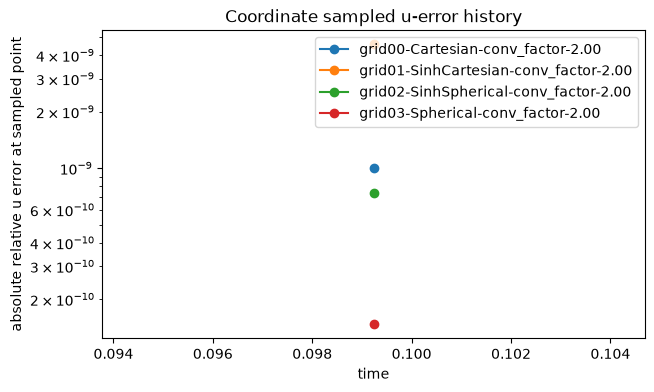

In [11]:
import matplotlib.pyplot as plt


plt.figure(figsize=(7, 4))
for diagnostic, rows in diagnostic_rows.items():
    positive_rows = [row for row in rows if abs(row[1]) > 0.0]
    times = [row[0] for row in positive_rows]
    errors = [abs(row[1]) for row in positive_rows]
    label = diagnostic.stem.replace("out0d-", "")
    plt.plot(times, errors, marker="o", label=label)
plt.yscale("log")
plt.xlabel("time")
plt.ylabel("absolute relative u error at sampled point")
plt.title("Coordinate sampled u-error history")
plt.legend()
plt.show()

The coordinate directories and runtime parameter file show one generated
project carrying several coordinate systems. The diagnostics demonstrate that
each grid writes its own sampled-error output using the same executable.

## Learning Check

After running, compare the generated coordinate directory names with the
expected options. Then list one thing that is shared and one thing that
differs between coordinates.

## Continue to Project Anatomy
- [GeneralRFM and Fisheye Coordinates](../4-curvilinear/generalrfm_and_fisheye.ipynb)
- [Curvilinear Boundary Conditions](../4-curvilinear/curvilinear_boundary_conditions.ipynb)
- [BHaH Project Anatomy](../5-infrastructures/bhah_project_anatomy.ipynb)